In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [17]:
df = pd.read_csv("../data/raw/delivery_data.csv")

print(df.shape)
df.head()

(144867, 24)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  str    
 1   trip_creation_time              144867 non-null  str    
 2   route_schedule_uuid             144867 non-null  str    
 3   route_type                      144867 non-null  str    
 4   trip_uuid                       144867 non-null  str    
 5   source_center                   144867 non-null  str    
 6   source_name                     144574 non-null  str    
 7   destination_center              144867 non-null  str    
 8   destination_name                144606 non-null  str    
 9   od_start_time                   144867 non-null  str    
 10  od_end_time                     144867 non-null  str    
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff                  

In [19]:
df.isnull().sum()

data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
segment_factor                      0
dtype: int64

In [20]:
df["route_type"].value_counts()

route_type
FTL        99660
Carting    45207
Name: count, dtype: int64

In [21]:
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [22]:
df["delay_ratio"] = df["actual_time"] / df["osrm_time"]

df["delay_ratio"].describe()

count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: delay_ratio, dtype: float64

In [23]:
print("Unique Source Centers:",
      df["source_center"].nunique())

print("Unique Destination Centers:",
      df["destination_center"].nunique())

Unique Source Centers: 1508
Unique Destination Centers: 1481


In [24]:
top_hubs = (
    df["source_center"]
    .value_counts()
    .head(20)
)

top_hubs

source_center
IND000000ACB    23347
IND562132AAA     9975
IND421302AAG     9088
IND411033AAA     4061
IND501359AAE     3340
IND712311AAA     2612
IND160002AAC     2450
IND395023AAA     2189
IND110037AAM     2013
IND560099AAB     1958
IND382430AAB     1760
IND131028AAB     1682
IND600056AAB     1678
IND781018AAB     1568
IND209304AAA     1513
IND751002AAB     1469
IND462022AAA     1450
IND560300AAA     1331
IND834002AAB     1074
IND854326AAB     1053
Name: count, dtype: int64

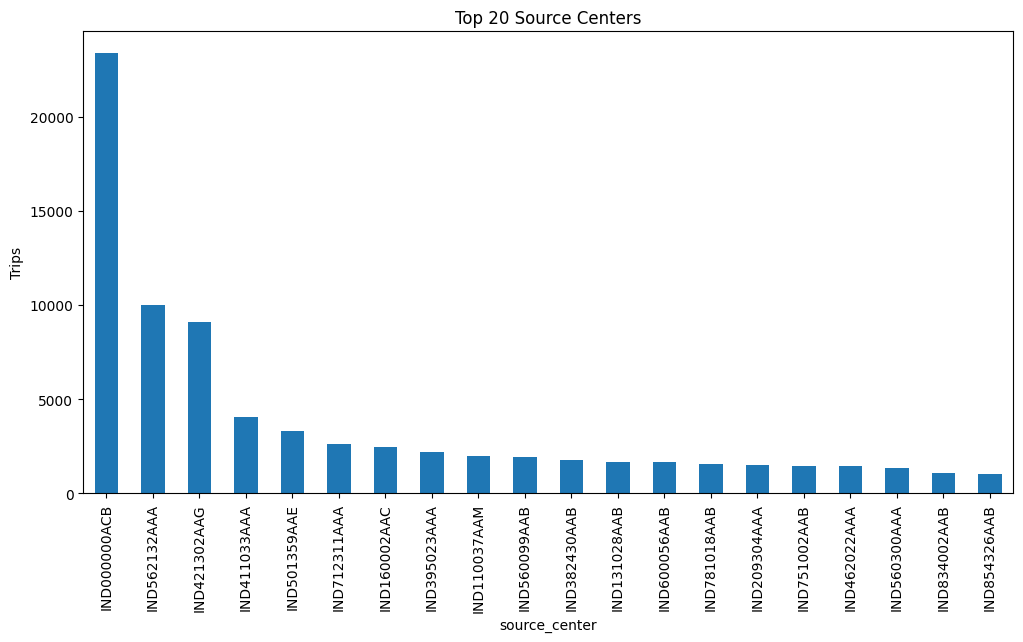

In [25]:
plt.figure(figsize=(12,6))

top_hubs.plot(kind="bar")

plt.title("Top 20 Source Centers")
plt.ylabel("Trips")

plt.show()

In [26]:
corridor_delay = (
    df.groupby(
        [
            "source_center",
            "destination_center"
        ]
    )["delay_ratio"]
    .mean()
    .reset_index()
)

corridor_delay.sort_values(
    "delay_ratio",
    ascending=False
).head(20)

,source_center,destination_center,delay_ratio
488,IND212402AAA,IND211002AAB,34.851053
2555,IND785634AAA,IND785001AAA,31.108333
2710,IND842003AAB,IND482002AAA,28.531250
1139,IND416606AAA,IND416510AAA,23.556107
956,IND395006AAA,IND395023AAD,23.502083
1208,IND424304AAC,IND424006AAA,22.313663
455,IND208012AAA,IND209304AAA,22.183624
485,IND211008AAA,IND211002AAB,20.189616
2347,IND722140AAA,IND723130AAA,19.130435
148,IND121002AAA,IND121004AAB,19.083333


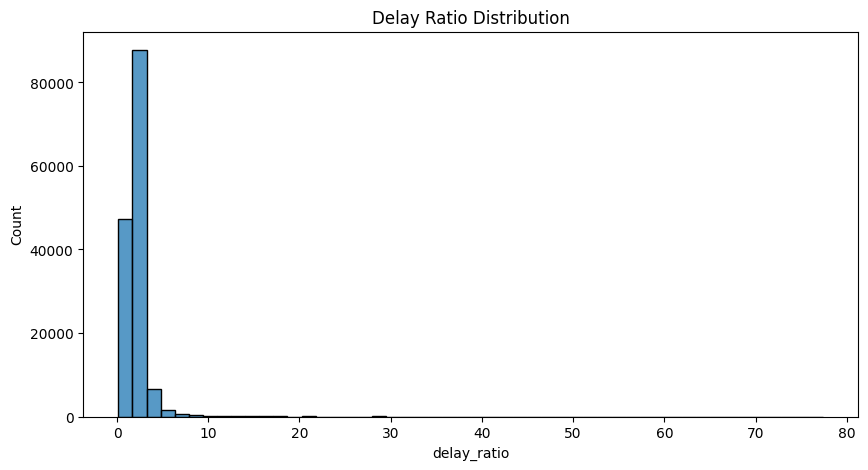

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["delay_ratio"],
    bins=50
)

plt.title("Delay Ratio Distribution")

plt.show()